## `plot()` method

Let us start by loading the data:

In [2]:
import pandas as pd

# Read in file 
df = pd.read_csv('data/wetlands_seasonal_bird_diversity.csv')

# Check the first 5 rows 
df.head()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
1,2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2,2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
3,2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
4,2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


A `pandas.DataFrame` has a built-in method plot() for plotting. When we call it without specifying any other parameters plot() creates one line plot for each of the columns with numeric data. 

<Axes: >

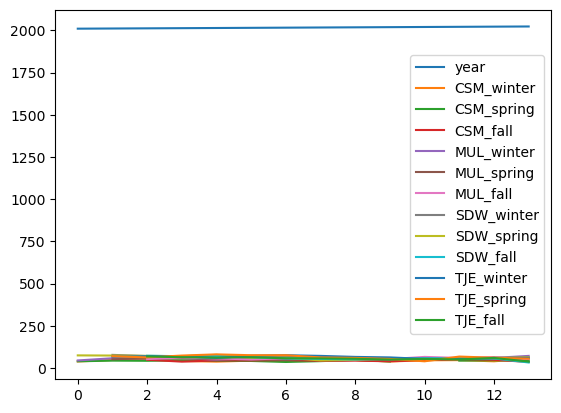

In [2]:
# Default plot(): one line plot per column with numeric data 
df.plot()

As we can see, this doesn't much sense! Since the `year` column is also numeric, it gets plotted as a line too, and its values (2010 to 2023) are so much larger than the species counts that all the other lines are squashed at the bottom of the graph. Also, look at the x-axis. The default for `plot` is to use the values of the index as the x-axis values. Let's see some examples about how to impove this situation.

## Line plots

We can make a line plot of one column against another by using the following general syntax:

In [3]:
df.plot(x='x_values_column', y='y_values_column')

KeyError: 'x_values_column'

### Example 

If we want to plot the bird surveys at Carpinteria Salt Marsh across years we can do:

<Axes: xlabel='year'>

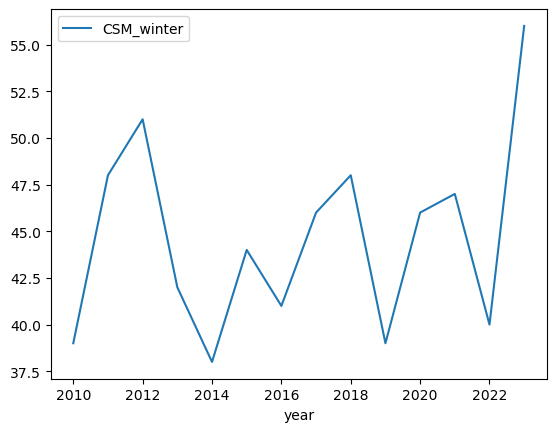

In [4]:
# Bird species registered during winter at CSM yearly 
df.plot(x='year', y='CSM_winter')

We can do some basic customization specifying other parameters of the plot() method. Some basic ones are:
* `title`: title to use for the plot
* `xlabel`: name to use for the x-label on x-axis
* `ylabel`: name to use for the y-label on y-axis
* `color`: change the color of our plot
* `legend`: boolean value `True` or `False`. `True` (default)         includes the legend, `False` removes the legend

In action:

<Axes: title={'center': 'Bird species registered during winter at Carpinteria Salt Marsh'}, xlabel='Year', ylabel='Number of bird species'>

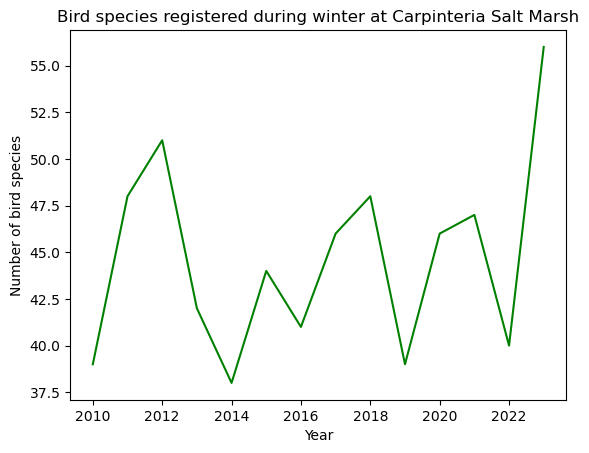

In [5]:
df.plot(x = 'year',
        y = 'CSM_winter',
        title = 'Bird species registered during winter at Carpinteria Salt Marsh',
        xlabel = 'Year',
        ylabel = 'Number of bird species',
        color = 'green',
        legend=False
)

### Check-In Assignment 

1. Plot a graph of the spring bird surveys at Mugu Lagoon with respect to the years. Include some basic customization.

2. Use the isna() method for pandas.Series and row selection to select the rows in which Mugu Lagoon has NAs during the spring survey.

<Axes: title={'center': 'Bird species registered during spring at Mugu Lagoon'}, xlabel='year', ylabel='Number of bird species'>

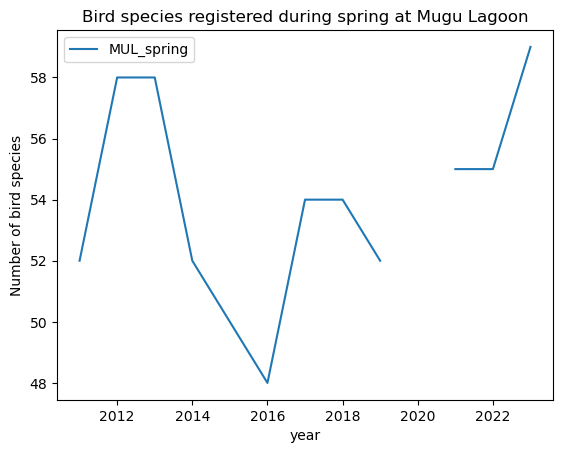

In [5]:
df.plot(x = 'year',
        y = 'MUL_spring',
        title = 'Bird species registered during spring at Mugu Lagoon',
        xlabel = 'year',
        ylabel = 'Number of bird species',
)

In [4]:
df[df['MUL_spring'].isna()]

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
10,2020,46.0,NaN,47.0,56.0,NaN,66.0,57.0,NaN,58.0,54.0,40.0,54.0


## Multiple line plots

We can plot multiple line plots by updating these parameters in the `plot()` method:

* `y:` a list of column names that will be plotted against the x-axis
* `color`: a dictionary
`{'column_1' : 'color_1', 'column_2':'color_2'}` specifying the color of each column's line plot

### Example 

Let's say we want to compare the bird surveys at the Tijuana Estuary during spring and fall across years.


<Axes: title={'center': 'Seasonal bird surveys at Tijuana Estuary'}, xlabel='Year', ylabel='Number of bird species'>

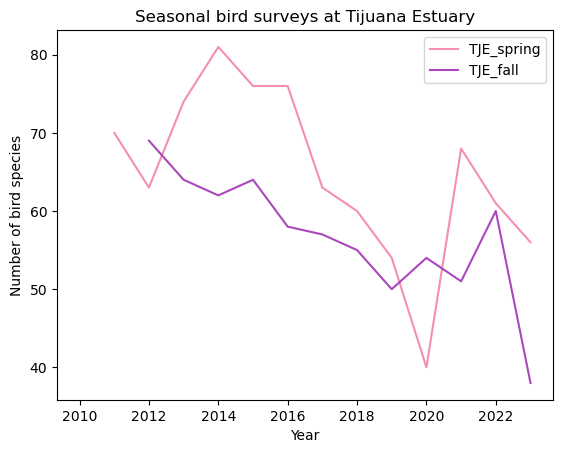

In [7]:
df.plot(x='year',
        y=['TJE_spring', 'TJE_fall'],
        title = 'Seasonal bird surveys at Tijuana Estuary',
        xlabel = 'Year',
        ylabel = 'Number of bird species',
        color = {'TJE_spring':'#F48FB1',
                 'TJE_fall': '#AB47BC'
                }
    
)

Notice that for specifying the colors we used a **HEX code**, this gives us more control over how our graph looks.

We can also create separate plots for each column by setting the `subplots` parameter to `True`.

df.plot(x='year', 
        y=['TJE_spring', 'TJE_fall'],
        title = 'Seasonal bird surveys at Tijuana Estuary',
        xlabel='Year',
        ylabel='Number of bird species',        
        color = {'TJE_spring':'#F48FB1',
                 'TJE_fall': '#AB47BC'
                 },
        subplots=True
        );

The semicolon `;` at the end of the code suppresses the text output of the `plot()` method, which is otherwise printed above the graph (here, an array with the two plot objects), so that only the graph is shown.

## Updating the index

**Updating the index** of our data frame to be something other than the default integers numbering the rows can be a useful operation for plotting. To update the index we use the set_index() method for a `pandas.DataFrame`. Its general syntax is:

In [ ]:
df = df.set_index(new_index)

Where `new_index` is:

* the name of the column in the data frame `df` we want to use as new index
* if our new index is not a column in the data frame, an array or `pandas.Series` of the same length as our data frame (we need one index per row).

This operation does not happen in-place.

* A function **acting in-place** means that our original object (in this case a `pandas.DataFrame`) is modified.
* If the fundtion **does not act in-place**, a new object (in this case a `pandas.DataFrame`) is created and the original is not modified.

If we wanted to update our `df` data frame we could do an **explicit assignment** to reassign the ouput of `set_index()` to `df`:

In [9]:
# Set `column_name` column in df as the new index (reassignment)
df = df.set_index('column_name')

KeyError: "None of ['column_name'] are in the columns"

or use the optional `inplace` parameter:

In [ ]:
# Set 'column_name' column in df as the new index (modify df in-place)
df.set_index('column_name', inplace=True)

### Example 

In all our previous examples we used the year column as the x-axis. Since all our bird survey variables are dependent on the year, it makes sense to use the year column as the index of the data frame:

In [10]:
# Update index to be the year column 
df = df.set_index('year')
df.head()

,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
year,,,,,,,,,,,,
2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


<Axes: xlabel='year'>

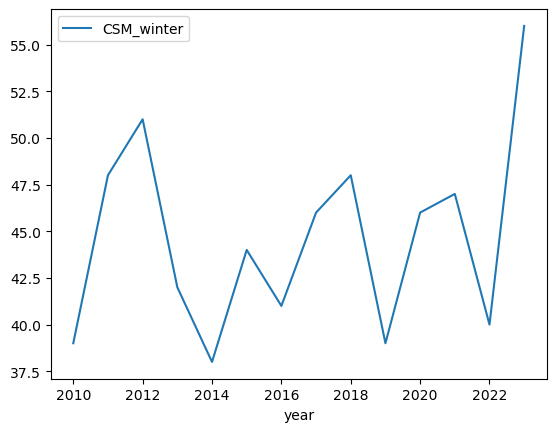

In [11]:
# Simple plot of Carpinteria Salt Marash winter surveys
df.plot(y='CSM_winter')

In [12]:
df = df.reset_index()
df.head()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
1,2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2,2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
3,2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
4,2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


### Check-In Assignment

1. Without running the code, give a step-by-step breakdown of what this code is doing:
`df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()`

2. Is this code modifying the data frame df? Why or why not?

3. Run the code and examine the graph. Review the data description. Do we have all the necessary information to make sure it makes sense to directly compare the surveys at these different sites?

In [ ]:
# The index is now set by year. Yes the code is modifying the data frame because the index is being changed. 
# The loc. method is just selecting all rows and columns from SDW_winter to TJE_fall.
# Yes we do. 

<Axes: xlabel='year'>

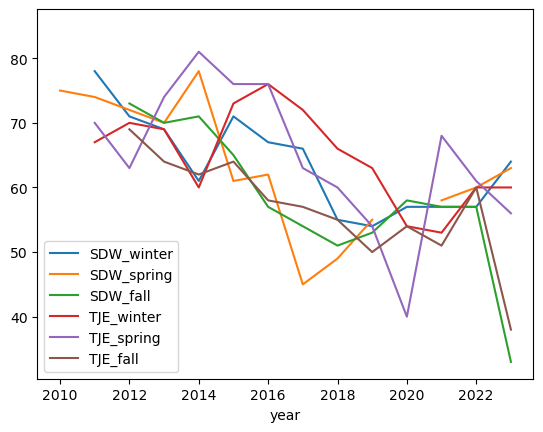

In [13]:
df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()


## Method Chaining

The code used in the check-in

<Axes: xlabel='year'>

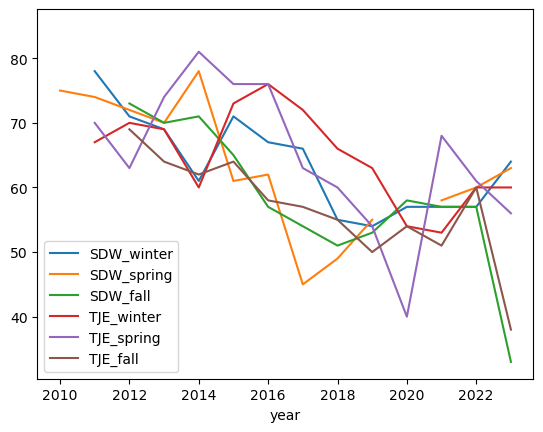

In [14]:
df.set_index('year').loc[:, 'SDW_winter': 'TJE_fall'].plot()

is an exmaple of **method chaining**. Each method in the chain returns a new obkect (usually a `pandas.DataFrame` or `pandas.Series`), allowing the next method to be called directly on the result. This is a powerful technique that makes code concise and readable. 

Chaining methods can result in lines of code that are too long and hard to read. We can break up chians of methods by using parentheses:

TypeError: 'Axes' object is not callable

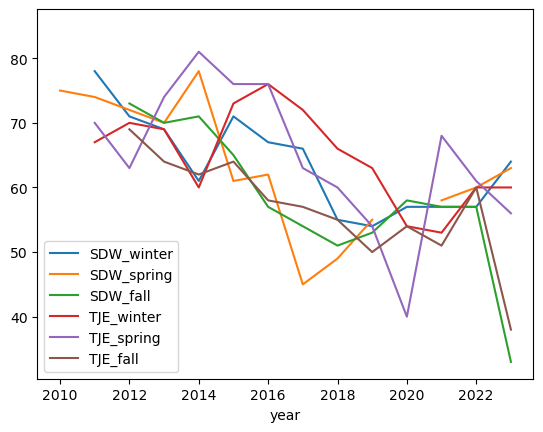

In [15]:
(df.set_index('year')
  .loc[:,'SDW_winter':'TJE_fall']
  .plot()
)()

### Check-In Assignment 

1. Select the bill_length_mm and bill_depth_mm columns in the penguins data frame and then update the kind parameter to box to make boxplots of the bill length and bill depth.

2. Create a simple histogram of the flipper length of female gentoo penguins.

In [16]:
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


<Axes: >

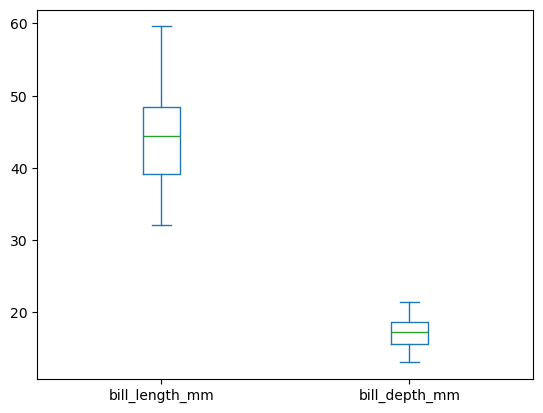

In [19]:
pengu_logistic = penguins.loc[:, 'bill_length_mm': 'bill_depth_mm']
pengu_logistic.plot(kind='box')

<Axes: ylabel='Frequency'>

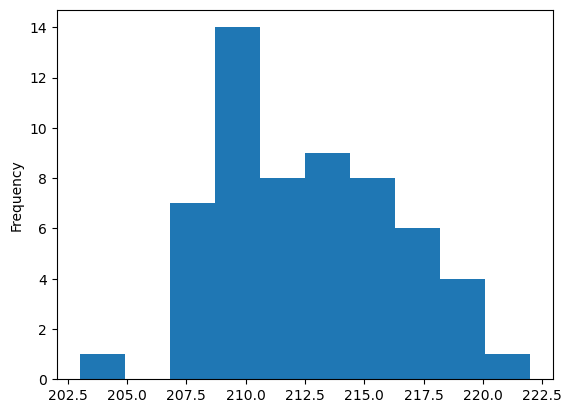

In [33]:
p1 = penguins[(penguins['species'] == 'Gentoo') & (penguins['sex'] == 'female')]['flipper_length_mm']
p1.plot(kind='hist')